# 05 — Final spatial diagnostics of out-of-fold classification errors

This notebook is a **post-estimation spatial diagnostic**. It does not fit, tune, compare or select predictive models.

It analyses the strictly out-of-fold predictions from the final dissertation model:

- **Model:** `random_forest_full19_raw`
- **Feature representation:** full 19-class semantic composition using raw proportions
- **Selection basis:** highest mean outer-fold macro-F1 in Notebook 04
- **Validation design:** immutable five-fold spatial cross-validation

The notebook evaluates whether prediction errors remain spatially clustered using:

1. Queen contiguity weights;
2. one-nearest-neighbour repair for genuine islands only;
3. Global Moran's I with permutation inference;
4. Benjamini–Hochberg correction across global tests;
5. exploratory Local Moran/LISA analysis of the primary probability residual;
6. Benjamini–Hochberg correction across local tests.

The primary local diagnostic is `observed_probability_residual`, defined as one minus the out-of-fold probability assigned to the observed class. It is a non-negative measure of prediction difficulty rather than a conventional signed regression residual.


## 1. Colab setup

In [1]:
from google.colab import drive
drive.mount("/content/drive")

In [2]:
!pip -q install geopandas pyogrio shapely libpysal esda mapclassify matplotlib statsmodels

## 2. Configuration

In [3]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
PERMUTATIONS = 9999
ALPHA = 0.05
np.random.seed(RANDOM_STATE)

PROJECT_DIR = Path("/content/drive/MyDrive/leeds_gsv_project")
OUTPUT_DIR = PROJECT_DIR / "outputs_10points_metadata_once"

# Definitive original grouped-versus-full model comparison.
MODELLING_DIR = (
    OUTPUT_DIR
    / "nested_spatial_modelling_grouped_vs_full19"
)

EXPECTED_SELECTED_MODEL = "random_forest_full19_raw"
EXPECTED_FOLDS = {1, 2, 3, 4, 5}
EXPECTED_N_ROWS = 488

SPATIAL_DIAGNOSTICS_DIR = (
    OUTPUT_DIR
    / "spatial_residual_diagnostics_random_forest_full19_raw"
)
FIGURE_DIR = SPATIAL_DIAGNOSTICS_DIR / "figures"

for folder in (SPATIAL_DIAGNOSTICS_DIR, FIGURE_DIR):
    folder.mkdir(parents=True, exist_ok=True)

OOF_FILE = (
    MODELLING_DIR
    / "selected_model_oof_spatial_diagnostics.csv"
)
GEOMETRY_FILE = (
    OUTPUT_DIR
    / "leeds_lsoa_targets_strict.gpkg"
)
FOLD_MAP_FILE = (
    OUTPUT_DIR
    / "lsoa_spatial_plus_fold_mapping.csv"
)

GLOBAL_MORAN_CSV = (
    SPATIAL_DIAGNOSTICS_DIR
    / "global_morans_i_oof_errors.csv"
)
WEIGHTS_AUDIT_CSV = (
    SPATIAL_DIAGNOSTICS_DIR
    / "spatial_weights_audit.csv"
)
LOCAL_MORAN_CSV = (
    SPATIAL_DIAGNOSTICS_DIR
    / "local_moran_selected_error.csv"
)
DIAGNOSTIC_GPKG = (
    SPATIAL_DIAGNOSTICS_DIR
    / "oof_spatial_diagnostics.gpkg"
)
SUMMARY_JSON = (
    SPATIAL_DIAGNOSTICS_DIR
    / "spatial_diagnostics_summary.json"
)

LSOA_ID_COL = "LSOA21CD"
FOLD_COL = "spatial_fold"

CLASS_ORDER = [
    "High Deprivation",
    "Medium Deprivation",
    "Low Deprivation",
]

RESIDUAL_COLUMNS = [
    "binary_error",
    "observed_probability_residual",
    "individual_log_loss",
    "multiclass_brier_contribution",
    "resid_high_deprivation",
    "resid_medium_deprivation",
    "resid_low_deprivation",
]

PRIMARY_LOCAL_VARIABLE = "observed_probability_residual"

print("OOF input:", OOF_FILE)
print("Geometry input:", GEOMETRY_FILE)
print("Frozen fold map:", FOLD_MAP_FILE)
print("Diagnostics output:", SPATIAL_DIAGNOSTICS_DIR)


## 3. Load and validate the OOF table and geometry

In [4]:
required_files = [OOF_FILE, GEOMETRY_FILE, FOLD_MAP_FILE]
missing = [str(path) for path in required_files if not path.exists()]

if missing:
    raise FileNotFoundError(
        "Required files are missing:\n- "
        + "\n- ".join(missing)
    )

oof = pd.read_csv(OOF_FILE)
gdf = gpd.read_file(GEOMETRY_FILE)
fold_map = pd.read_csv(FOLD_MAP_FILE)

required_oof_columns = {
    LSOA_ID_COL,
    "model",
    FOLD_COL,
    "observed_idx",
    "predicted_idx",
    "correct",
    "observed_class_probability",
    *RESIDUAL_COLUMNS,
}

missing_oof = sorted(
    required_oof_columns.difference(oof.columns)
)
if missing_oof:
    raise KeyError(
        "OOF file is missing required columns: "
        f"{missing_oof}"
    )

for name, frame in {
    "OOF": oof,
    "geometry": gdf,
    "fold map": fold_map,
}.items():
    if len(frame) != EXPECTED_N_ROWS:
        raise ValueError(
            f"{name} has {len(frame)} rows; "
            f"expected {EXPECTED_N_ROWS}."
        )

    if frame[LSOA_ID_COL].isna().any():
        raise ValueError(
            f"{name} contains missing LSOA identifiers."
        )

    if frame[LSOA_ID_COL].duplicated().any():
        raise ValueError(
            f"{name} contains duplicate LSOA identifiers."
        )

if oof["model"].nunique(dropna=False) != 1:
    raise ValueError(
        "The selected-model OOF file must contain exactly one model."
    )

loaded_model = str(oof["model"].iloc[0])

if loaded_model != EXPECTED_SELECTED_MODEL:
    raise ValueError(
        "Unexpected selected model in the OOF file. "
        f"Expected {EXPECTED_SELECTED_MODEL!r}, "
        f"found {loaded_model!r}."
    )

oof[FOLD_COL] = pd.to_numeric(
    oof[FOLD_COL],
    errors="raise",
).astype(int)

observed_folds = set(oof[FOLD_COL].unique())
if observed_folds != EXPECTED_FOLDS:
    raise ValueError(
        f"Expected frozen folds {sorted(EXPECTED_FOLDS)}, "
        f"found {sorted(observed_folds)}."
    )

if not oof["correct"].isin([0, 1, False, True]).all():
    raise ValueError(
        "The 'correct' field is not binary."
    )

oof["correct"] = oof["correct"].astype(int)
oof["binary_error"] = pd.to_numeric(
    oof["binary_error"],
    errors="raise",
).astype(int)

expected_binary_error = 1 - oof["correct"]

if not np.array_equal(
    oof["binary_error"].to_numpy(),
    expected_binary_error.to_numpy(),
):
    raise ValueError(
        "binary_error is inconsistent with the 'correct' field."
    )

oof["observed_class_probability"] = pd.to_numeric(
    oof["observed_class_probability"],
    errors="raise",
)

oof["observed_probability_residual"] = pd.to_numeric(
    oof["observed_probability_residual"],
    errors="raise",
)

if not oof["observed_class_probability"].between(0, 1).all():
    raise ValueError(
        "observed_class_probability contains values outside [0, 1]."
    )

if not oof["observed_probability_residual"].between(0, 1).all():
    raise ValueError(
        "observed_probability_residual contains values outside [0, 1]."
    )

expected_probability_residual = (
    1.0 - oof["observed_class_probability"]
)

if not np.allclose(
    oof["observed_probability_residual"],
    expected_probability_residual,
    atol=1e-10,
):
    raise ValueError(
        "observed_probability_residual is inconsistent with "
        "1 - observed_class_probability."
    )

for column in RESIDUAL_COLUMNS:
    oof[column] = pd.to_numeric(
        oof[column],
        errors="raise",
    )

if not np.isfinite(
    oof[RESIDUAL_COLUMNS].to_numpy(dtype=float)
).all():
    raise ValueError(
        "One or more residual variables contain NaN or infinite values."
    )

if LSOA_ID_COL not in gdf.columns:
    raise KeyError(
        f"Geometry file does not contain {LSOA_ID_COL}."
    )

if gdf.crs is None:
    raise ValueError(
        "LSOA geometry has no coordinate reference system."
    )

if gdf.geometry.isna().any():
    raise ValueError(
        "LSOA geometry contains missing geometries."
    )

if gdf.geometry.is_empty.any():
    raise ValueError(
        "LSOA geometry contains empty geometries."
    )

if not gdf.geometry.is_valid.all():
    invalid_count = int(
        (~gdf.geometry.is_valid).sum()
    )
    raise ValueError(
        f"LSOA geometry contains {invalid_count} invalid geometries. "
        "Repair these upstream rather than silently modifying them here."
    )

spatial = gdf[[LSOA_ID_COL, "geometry"]].merge(
    oof,
    on=LSOA_ID_COL,
    how="inner",
    validate="one_to_one",
)

if len(spatial) != EXPECTED_N_ROWS:
    missing_geometry_ids = sorted(
        set(oof[LSOA_ID_COL]).difference(
            spatial[LSOA_ID_COL]
        )
    )
    raise ValueError(
        "The OOF-to-geometry join did not retain all Leeds LSOAs. "
        f"Unmatched examples: {missing_geometry_ids[:10]}"
    )

spatial = gpd.GeoDataFrame(
    spatial,
    geometry="geometry",
    crs=gdf.crs,
)

fold_check = spatial[
    [LSOA_ID_COL, FOLD_COL]
].merge(
    fold_map[[LSOA_ID_COL, FOLD_COL]],
    on=LSOA_ID_COL,
    suffixes=("_oof", "_frozen"),
    validate="one_to_one",
)

if not (
    fold_check[f"{FOLD_COL}_oof"].astype(int)
    == fold_check[f"{FOLD_COL}_frozen"].astype(int)
).all():
    raise ValueError(
        "OOF fold labels disagree with the frozen spatial fold map."
    )

spatial = spatial.sort_values(
    LSOA_ID_COL
).reset_index(drop=True)

print("Selected model:", loaded_model)
print("Frozen folds:", sorted(observed_folds))
print("Joined spatial table shape:", spatial.shape)

display(
    spatial[RESIDUAL_COLUMNS]
    .describe()
    .T
)


Selected model: random_forest_full19_raw
Frozen folds: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Joined spatial table shape: (488, 24)


                               count      mean       std       min       25%  \
binary_error                   488.0  0.452869  0.498284  0.000000  0.000000   
observed_probability_residual  488.0  0.584287  0.149506  0.118662  0.493279   
individual_log_loss            488.0  0.947101  0.386194  0.126314  0.679795   
multiclass_brier_contribution  488.0  0.566964  0.267979  0.021445  0.375508   
resid_high_deprivation         488.0  0.016517  0.435231 -0.802728 -0.311369   
resid_medium_deprivation       488.0 -0.028460  0.452126 -0.566617 -0.349769   
resid_low_deprivation          488.0  0.011943  0.416001 -0.805515 -0.278551   

                                    50%       75%       max  
binary_error                   0.000000  1.000000  1.000000  
observed_probability_residual  0.597689  0.690819  0.904485  
individual_log_loss            0.910532  1.173829  2.348473  
multiclass_brier_contribution  0.547273  0.741908  1.425276  
resid_high_deprivation        -0.181694  0.487570

## 4. Construct and audit spatial weights

Queen contiguity is used as the primary specification because LSOAs sharing either an edge or a vertex are treated as neighbours. Islands are not silently accepted. Where contiguity produces islands, the notebook connects each island to its nearest polygon centroid and records that intervention.

In [5]:
from libpysal.weights import Queen, KNN
from libpysal.weights.util import attach_islands

# Queen contiguity is the primary neighbourhood definition.
# A projected CRS is used for nearest-neighbour distance calculations.
spatial_projected = (
    spatial.to_crs(27700)
    if spatial.crs.is_geographic
    else spatial.copy()
)

ids = spatial_projected[LSOA_ID_COL].tolist()

w_queen = Queen.from_dataframe(
    spatial_projected,
    ids=ids,
    use_index=False,
)

initial_islands = list(w_queen.islands)

# Repair genuine islands only, using one nearest neighbour.
if initial_islands:
    w_knn1 = KNN.from_dataframe(
        spatial_projected,
        k=1,
        ids=ids,
        use_index=False,
    )
    w_queen = attach_islands(
        w_queen,
        w_knn1,
    )

remaining_islands = list(w_queen.islands)

if remaining_islands:
    raise ValueError(
        "Spatial weights still contain islands: "
        f"{remaining_islands}"
    )

if w_queen.n_components != 1:
    raise ValueError(
        "The final spatial weights graph is not fully connected. "
        f"Connected components: {w_queen.n_components}"
    )

w_queen.transform = "r"

cardinalities = np.array(
    list(w_queen.cardinalities.values()),
    dtype=int,
)

weights_audit = pd.DataFrame({
    "metric": [
        "n_lsoas",
        "initial_islands",
        "remaining_islands",
        "n_components",
        "minimum_neighbours",
        "median_neighbours",
        "maximum_neighbours",
        "weights_transform",
    ],
    "value": [
        int(w_queen.n),
        int(len(initial_islands)),
        int(len(remaining_islands)),
        int(w_queen.n_components),
        int(cardinalities.min()),
        float(np.median(cardinalities)),
        int(cardinalities.max()),
        "row-standardised",
    ],
})

weights_audit.to_csv(
    WEIGHTS_AUDIT_CSV,
    index=False,
)

display(weights_audit)
print("Initial islands repaired:", initial_islands)


               metric             value
0             n_lsoas               488
1     initial_islands                 0
2   remaining_islands                 0
3        n_components                 1
4  minimum_neighbours                 1
5   median_neighbours               6.0
6  maximum_neighbours                14
7   weights_transform  row-standardised

Initial islands repaired: []


## 5. Map out-of-fold error variables

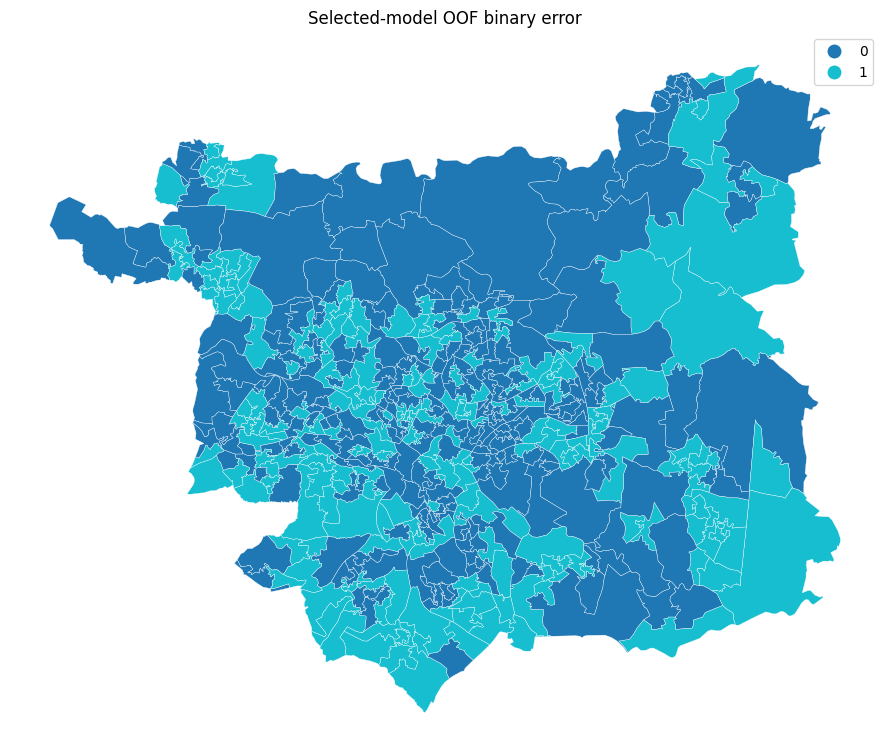

Saved: <PROJECT_DIR>/outputs_10points_metadata_once/spatial_residual_diagnostics_random_forest_full19_raw/figures/map_binary_error.png


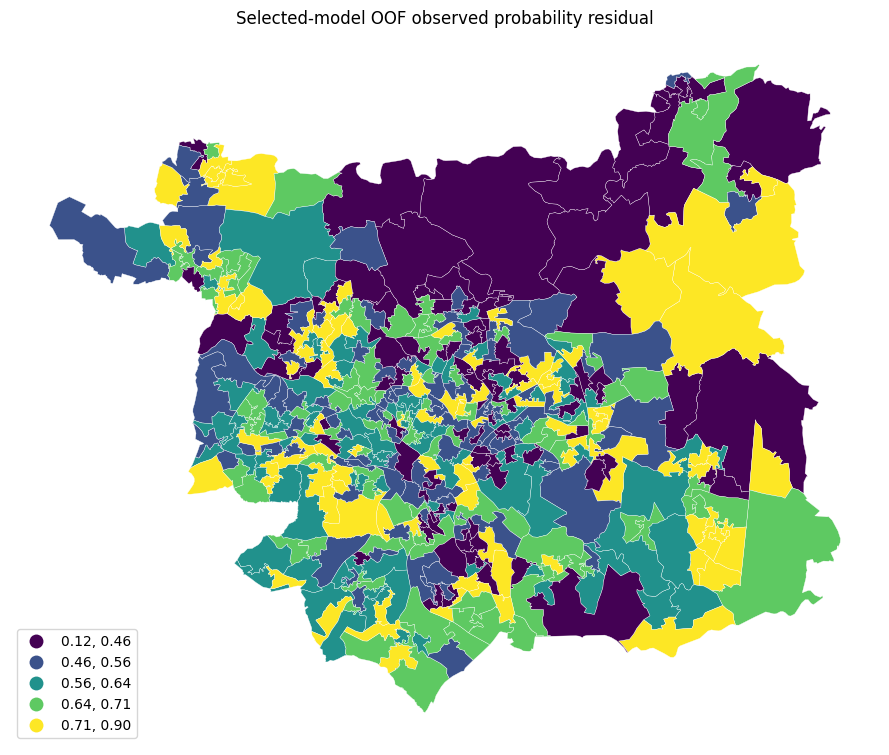

Saved: <PROJECT_DIR>/outputs_10points_metadata_once/spatial_residual_diagnostics_random_forest_full19_raw/figures/map_observed_probability_residual.png


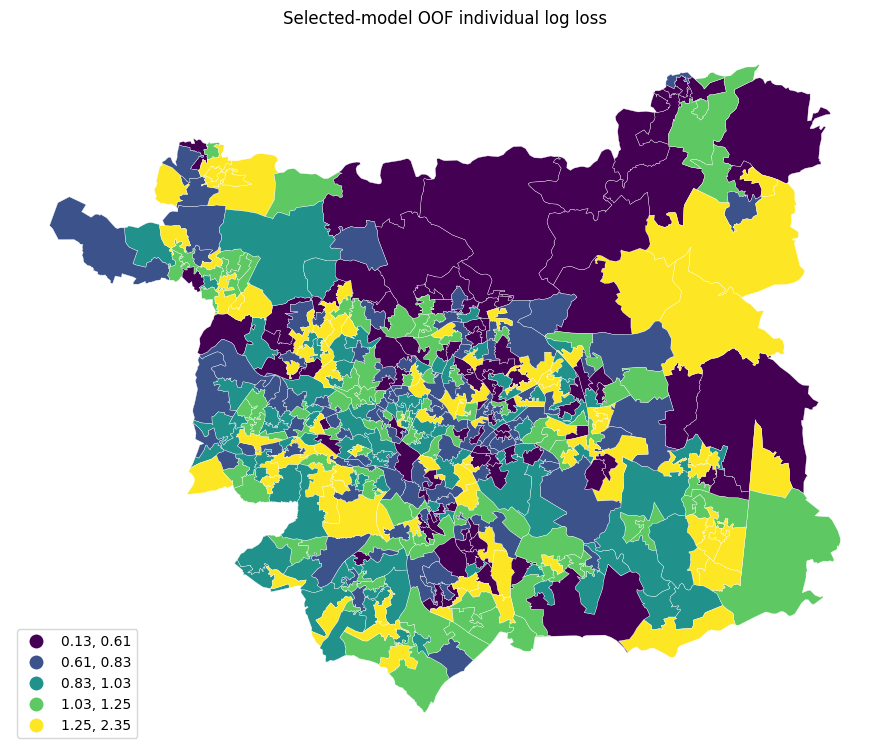

Saved: <PROJECT_DIR>/outputs_10points_metadata_once/spatial_residual_diagnostics_random_forest_full19_raw/figures/map_individual_log_loss.png


In [6]:
map_variables = [
    "binary_error",
    "observed_probability_residual",
    "individual_log_loss",
]

for variable in map_variables:
    fig, ax = plt.subplots(figsize=(9, 9))

    common_kwargs = {
        "column": variable,
        "ax": ax,
        "legend": True,
        "edgecolor": "white",
        "linewidth": 0.25,
    }

    if spatial[variable].nunique() > 2:
        spatial.plot(
            scheme="quantiles",
            k=5,
            legend_kwds={"loc": "lower left"},
            **common_kwargs,
        )
    else:
        spatial.plot(
            categorical=True,
            **common_kwargs,
        )

    ax.set_title(
        "Selected-model OOF "
        + variable.replace("_", " ")
    )
    ax.set_axis_off()
    plt.tight_layout()

    path = FIGURE_DIR / f"map_{variable}.png"
    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    print("Saved:", path)


## 6. Global Moran’s I

Inference is based on random permutations. The binary-error statistic answers whether incorrect classifications cluster. The continuous probability residuals and scoring-rule contributions additionally reflect confidence and severity.

In [7]:
from esda.moran import Moran
from statsmodels.stats.multitest import multipletests

GLOBAL_DESCRIPTIONS = {
    "binary_error": (
        "Binary out-of-fold misclassification indicator"
    ),
    "observed_probability_residual": (
        "One minus the OOF probability assigned to the observed class"
    ),
    "individual_log_loss": (
        "Observation-level multiclass log-loss contribution"
    ),
    "multiclass_brier_contribution": (
        "Observation-level multiclass Brier contribution"
    ),
    "resid_high_deprivation": (
        "Signed OOF probability residual for High Deprivation"
    ),
    "resid_medium_deprivation": (
        "Signed OOF probability residual for Medium Deprivation"
    ),
    "resid_low_deprivation": (
        "Signed OOF probability residual for Low Deprivation"
    ),
}

moran_rows = []

for variable in RESIDUAL_COLUMNS:
    values = (
        spatial.set_index(LSOA_ID_COL)
        .loc[w_queen.id_order, variable]
        .to_numpy(dtype=float)
    )

    if np.isclose(np.var(values), 0.0):
        moran_rows.append({
            "variable": variable,
            "description": GLOBAL_DESCRIPTIONS[variable],
            "n": len(values),
            "moran_i": np.nan,
            "expected_i": np.nan,
            "z_sim": np.nan,
            "p_sim_two_sided": np.nan,
            "permutations": PERMUTATIONS,
            "note": "Zero variance; Moran's I undefined.",
        })
        continue

    result = Moran(
        values,
        w_queen,
        permutations=PERMUTATIONS,
        two_tailed=True,
    )

    # Exact two-sided permutation pseudo-p value around the
    # randomisation expectation.
    observed_distance = abs(
        result.I - result.EI
    )
    simulated_distance = np.abs(
        np.asarray(result.sim) - result.EI
    )

    p_two = (
        1.0
        + np.sum(
            simulated_distance >= observed_distance
        )
    ) / (PERMUTATIONS + 1.0)

    moran_rows.append({
        "variable": variable,
        "description": GLOBAL_DESCRIPTIONS[variable],
        "n": len(values),
        "moran_i": float(result.I),
        "expected_i": float(result.EI),
        "z_sim": float(result.z_sim),
        "p_sim_two_sided": float(p_two),
        "permutations": PERMUTATIONS,
        "note": "",
    })

global_moran = pd.DataFrame(moran_rows)

valid_mask = global_moran[
    "p_sim_two_sided"
].notna()

global_moran["p_fdr_bh"] = np.nan

if valid_mask.any():
    global_moran.loc[
        valid_mask,
        "p_fdr_bh",
    ] = multipletests(
        global_moran.loc[
            valid_mask,
            "p_sim_two_sided",
        ],
        alpha=ALPHA,
        method="fdr_bh",
    )[1]

global_moran[
    "significant_0_05_unadjusted"
] = (
    global_moran["p_sim_two_sided"]
    < ALPHA
)

global_moran[
    "significant_fdr_0_05"
] = (
    global_moran["p_fdr_bh"]
    < ALPHA
)

global_moran = global_moran.sort_values(
    "p_fdr_bh",
    na_position="last",
)

global_moran.to_csv(
    GLOBAL_MORAN_CSV,
    index=False,
)

display(global_moran)
print("Saved:", GLOBAL_MORAN_CSV)


                        variable  \
0                   binary_error   
1  observed_probability_residual   
2            individual_log_loss   
3  multiclass_brier_contribution   
4         resid_high_deprivation   
5       resid_medium_deprivation   
6          resid_low_deprivation   

                                         description    n   moran_i  \
0     Binary out-of-fold misclassification indicator  488  0.128203   
1  One minus the OOF probability assigned to the ...  488  0.203576   
2  Observation-level multiclass log-loss contribu...  488  0.176461   
3    Observation-level multiclass Brier contribution  488  0.184929   
4  Signed OOF probability residual for High Depri...  488  0.373132   
5  Signed OOF probability residual for Medium Dep...  488  0.143542   
6  Signed OOF probability residual for Low Depriv...  488  0.214987   

   expected_i      z_sim  p_sim_two_sided  permutations note  p_fdr_bh  \
0   -0.002053   4.718601           0.0001          9999         0.00

Saved: <PROJECT_DIR>/outputs_10points_metadata_once/spatial_residual_diagnostics_random_forest_full19_raw/global_morans_i_oof_errors.csv


## 7. Exploratory local Moran/LISA for the primary probability residual

Local clusters are evaluated for `observed_probability_residual`, not the binary indicator, because it preserves confidence information. False-discovery-rate correction is applied across the 488 local tests. LISA results are exploratory and should not replace the global test.

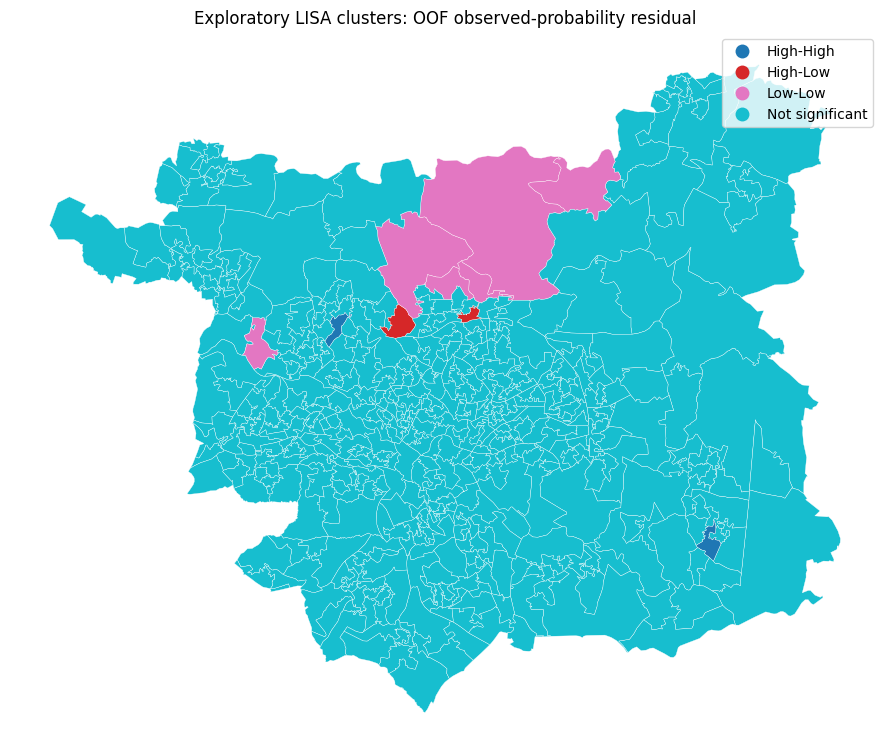

                 n_lsoas
cluster                 
Not significant      478
Low-Low                6
High-High              2
High-Low               2

Saved: <PROJECT_DIR>/outputs_10points_metadata_once/spatial_residual_diagnostics_random_forest_full19_raw/local_moran_selected_error.csv
Saved: <PROJECT_DIR>/outputs_10points_metadata_once/spatial_residual_diagnostics_random_forest_full19_raw/figures/lisa_observed_probability_residual_fdr.png


In [8]:
from esda.moran import Moran_Local
from statsmodels.stats.multitest import multipletests

values = (
    spatial.set_index(LSOA_ID_COL)
    .loc[
        w_queen.id_order,
        PRIMARY_LOCAL_VARIABLE,
    ]
    .to_numpy(dtype=float)
)

if np.isclose(np.var(values), 0.0):
    raise ValueError(
        f"{PRIMARY_LOCAL_VARIABLE} has zero variance; "
        "Local Moran's I is undefined."
    )

local = Moran_Local(
    values,
    w_queen,
    permutations=PERMUTATIONS,
    seed=RANDOM_STATE,
)

local_df = pd.DataFrame({
    LSOA_ID_COL: w_queen.id_order,
    "primary_variable": PRIMARY_LOCAL_VARIABLE,
    "local_i": local.Is,
    "quadrant": local.q,
    "p_sim": local.p_sim,
})

local_df["p_fdr_bh"] = multipletests(
    local_df["p_sim"],
    alpha=ALPHA,
    method="fdr_bh",
)[1]

local_df[
    "significant_0_05_unadjusted"
] = (
    local_df["p_sim"] < ALPHA
)

local_df[
    "significant_fdr_0_05"
] = (
    local_df["p_fdr_bh"] < ALPHA
)

quadrant_names = {
    1: "High-High",
    2: "Low-High",
    3: "Low-Low",
    4: "High-Low",
}

local_df["quadrant_name"] = (
    local_df["quadrant"]
    .map(quadrant_names)
    .fillna("Undefined")
)

local_df["lisa_cluster_fdr"] = np.where(
    local_df["significant_fdr_0_05"],
    local_df["quadrant_name"],
    "Not significant",
)

local_df.to_csv(
    LOCAL_MORAN_CSV,
    index=False,
)

spatial = spatial.merge(
    local_df,
    on=LSOA_ID_COL,
    how="left",
    validate="one_to_one",
)

fig, ax = plt.subplots(figsize=(9, 9))

spatial.plot(
    column="lisa_cluster_fdr",
    categorical=True,
    legend=True,
    ax=ax,
    edgecolor="white",
    linewidth=0.25,
)

ax.set_title(
    "Exploratory LISA clusters: "
    "OOF observed-probability residual"
)
ax.set_axis_off()
plt.tight_layout()

lisa_path = (
    FIGURE_DIR
    / "lisa_observed_probability_residual_fdr.png"
)

plt.savefig(
    lisa_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

display(
    local_df["lisa_cluster_fdr"]
    .value_counts(dropna=False)
    .rename_axis("cluster")
    .to_frame("n_lsoas")
)

print("Saved:", LOCAL_MORAN_CSV)
print("Saved:", lisa_path)


## 8. Export spatial layer and audit outputs

In [9]:
if DIAGNOSTIC_GPKG.exists():
    DIAGNOSTIC_GPKG.unlink()

spatial.to_file(
    DIAGNOSTIC_GPKG,
    layer="oof_diagnostics",
    driver="GPKG",
)

summary = {
    "notebook": "05_oof_spatial_residual_diagnostics.ipynb",
    "selected_model": EXPECTED_SELECTED_MODEL,
    "model_selection_basis": (
        "Highest mean outer-fold macro-F1 in the original "
        "grouped-versus-full nested spatial comparison."
    ),
    "oof_file": str(OOF_FILE),
    "geometry_file": str(GEOMETRY_FILE),
    "frozen_fold_map": str(FOLD_MAP_FILE),
    "n_lsoas": int(len(spatial)),
    "frozen_spatial_folds": sorted(EXPECTED_FOLDS),
    "weights": (
        "Queen contiguity; one-nearest-neighbour links "
        "added only for genuine islands."
    ),
    "initial_islands": [
        str(value)
        for value in initial_islands
    ],
    "remaining_islands": [
        str(value)
        for value in remaining_islands
    ],
    "n_components": int(
        w_queen.n_components
    ),
    "permutations": PERMUTATIONS,
    "random_state": RANDOM_STATE,
    "global_variables": RESIDUAL_COLUMNS,
    "global_multiple_testing": (
        "Benjamini-Hochberg FDR at 0.05"
    ),
    "primary_local_variable": (
        PRIMARY_LOCAL_VARIABLE
    ),
    "local_multiple_testing": (
        "Benjamini-Hochberg FDR at 0.05"
    ),
    "interpretation_note": (
        "observed_probability_residual equals one minus "
        "the strictly out-of-fold probability assigned "
        "to the observed class. It is a non-negative "
        "prediction-difficulty measure rather than a "
        "conventional signed regression residual."
    ),
}

with open(
    SUMMARY_JSON,
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        summary,
        handle,
        indent=2,
    )

expected_outputs = [
    GLOBAL_MORAN_CSV,
    WEIGHTS_AUDIT_CSV,
    LOCAL_MORAN_CSV,
    DIAGNOSTIC_GPKG,
    SUMMARY_JSON,
]

audit = pd.DataFrame({
    "path": [
        str(path)
        for path in expected_outputs
    ],
    "exists": [
        path.exists()
        for path in expected_outputs
    ],
    "size_bytes": [
        (
            path.stat().st_size
            if path.exists()
            else np.nan
        )
        for path in expected_outputs
    ],
})

display(audit)

if not audit["exists"].all():
    raise FileNotFoundError(
        "One or more expected Notebook 05 outputs "
        "were not created."
    )

print("Notebook 05 output audit passed.")


                                                path  exists  size_bytes
0  <PROJECT_DIR>/outpu...    True        1325
1  <PROJECT_DIR>/outpu...    True         178
2  <PROJECT_DIR>/outpu...    True       60212
3  <PROJECT_DIR>/outpu...    True      819200
4  <PROJECT_DIR>/outpu...    True        1659

Notebook 05 output audit passed.


## Interpretation notes for Chapter 4

1. Moran's I evaluates spatial pattern in **strictly out-of-fold predictive errors**, not causal spatial effects.
2. The Benjamini–Hochberg adjusted global results should receive priority when discussing statistical significance.
3. `observed_probability_residual` equals one minus the probability assigned to the observed class. It measures prediction difficulty or lack of confidence and is not a conventional signed regression residual.
4. Local Moran/LISA results are exploratory and should be described as possible local concentrations of unusually high or low prediction difficulty.
5. Report both unadjusted and FDR-adjusted local results, but emphasise or map the FDR-adjusted classifications.
6. Binary-error Moran's I is secondary because the variable is discrete and contains many ties; permutation inference nevertheless provides a defensible randomisation assessment.
7. Do not use these diagnostics to retune, replace or reselect the final predictive model.
8. Significant residual clustering would indicate that semantic composition alone does not capture all spatially structured determinants associated with deprivation.
9. Non-significant residual autocorrelation would support the conclusion that the model errors do not exhibit strong remaining global spatial structure under the specified weights.
